- 웹 통신의 기초 : 클라이언트의 요청 -> 서버의 응답 의 구조!
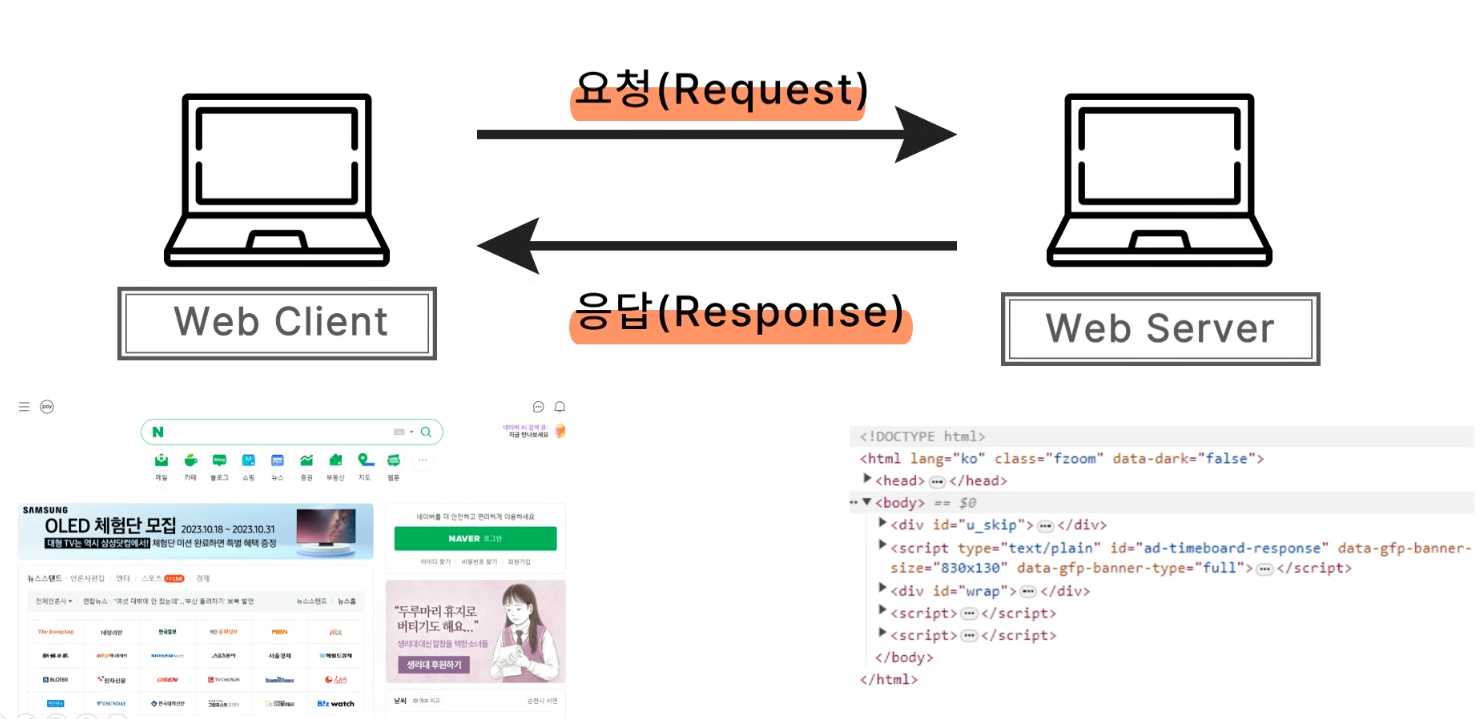

### flask 서버
 - 서버 : 웹, 어플리케이션을 구동하기 위한 가상의 컴퓨터(백엔드)
 - 역할 : 프론트에서 보낸 데이터를 처리하는 역할 등
 - ex> 회원가입 정보 입력(html) -> 데이터를 전송(서버로) -> DB 서버에 저장
    - 만약에, 데이터 전송 서버 없이 DB 서버로 저장할 순 없을까?
     - 가능은 함! but, 바이러스를 넣었다면 거르지 못하고 저장되는 문제가 발생한다!
     - 중간에 데이터가 잘 넘어오는지 걸러주는 역할을 서버로 구축!
     - 데이터가 잘 넘어오는지 : 값이 모두 잘 채워졌는지(아이디 비번 등)
     - 서버 자체가 필터는 아니지만, 필터링의 역할을 할 수 있다!

- 우리가 이미 실습 때 사용해본 서버 : vscode를 활용 -> live server
- live server : vscode에 설치해서 사용하는 테스트용 서버 -> 코드 수정이 불가능(내가 원하는 식으로
서버를 구축할 수 없다. ex> 필터링 역할 등), 단순하게 웹페이지의 생김새를 보여주는 역할의 서버
- flask server : 파이썬 언어로 내가 직접 제작하는 서버 -> 내가 원하는 기능 제작 가능, 파이썬 파일의
구동이 편함

---

-  우리가 오늘 배울 것 : 서버의 기본 구조, 동작 원리, 요청과 응답에 대한 개념 정리
-  우리가 추후 배울 것 : JS(node.js)로 서버 제작 (웹에 더 적합한 기능을 제작하는 서버)

In [12]:
# 원칙적으로는 라이브러리 설치가 우선!
# 우리가 사용해본 라이브러리(numpy, pandas, matplotlib) -> 아나콘다 환경에서 이미 설치가 됨

# 설치하는 방법!
# 방법 1. anaconda prompt 실행(검은 창 뜸) -> 설치
# 방법 2. 주피터 노트북에서 설치하기
# ! : '해당 줄은 파이썬 코드가 아니라 시스템 명령어다' 라고 알려주는 역할
# pip : ptyhon installer package / 설치/ 삭제 등을 할 수 있는 패키지(폴더) 관리 도구
#!pip install Flask      # pip install 설치할패키지이름   ->아나콘다 프롬프트에서는 느낌표 빼고 하면 됨      

### flask 서버 기본 구조
 - 서버의 제작 순서
   1. 미리 만들어진 서버의 설계도면을 호출
   2. 서버의 역할 정의 (무슨 일을 할건지를 적어준다)
   3. 완성본을 실행하는 코드를 작성  

In [2]:
# 플라스크 라이브러리 불러오기
from flask import Flask

In [3]:
# 가장 기본적인 구조 설계

# 1. 미리 만들어진 서버의 설계도면을 호출해서 변수에 담기
# flask() : 만들어진 falsk 서버 설계 도면을 호출하는 함수
# __ : 던더
# __name__ : 현재 작성중인 파일을 기준으로 하겠다(일종의 키워드. 국룰?) 
# -> __main__ 이름으로 자동으로 변경
app = Flask(__name__)
# flask 설계도면을 가져와서 현재 작성중인 파일에 서버를 제작하고 app이라는 변수에 담겠다


# 2. 서버의 역할 정의 : 만든 서버를 가지고 역할을 정의하는 단계
# @(데코레이터) : 바로 밑에 정의할 함수에 기능을 추가하겠다
# app : 우리가 만든 서버
# route() : 경로 설정 -> 사용자가 요청한 경로를 해석하는 역할
# '/' : 기본값 설정, 메인 경로를 의미    슬래시 뒤에 경로를 추가해줄수 있음. 라우트를 만들어가는
# 서버에 경로를 분석해서 정의된 함수의 리턴값을 반환
@app.route('/')
def hello(): # 함수를 정의해서
    return 'hello world' # 리턴값을 반환(응답)하겠다

# 클라이언트가 요청한다-> 링크를 클릭(입력)
# 해당 링크(경로)를 확인해서 응답


# 3. 완성본을 실행하는 코드
# 만약에 __name__이 __main__과 같다면
# 우리가 만든 서버(app)를 실행해라(run)
# host는 localhost -> 내 컴퓨터로(127.0.0.1)만 하겠다
# 만약에, 아무나 접근 가능하게 하고싶다면? 'localhost' 대신 '0.0.0.0'
# 포트번호 : 은행 창구번호 같은 것. 중복되면 X ->플라스크 포트넘버는 5000을 쓰는게 관습이다.
if __name__ == '__main__':
    app.run(host = 'localhost', port = 5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://localhost:5000
Press CTRL+C to quit


### 여러 개의 요청 처리하기
 - 요청이 여러 개인 경우에는 응답도 여러 개 필요하다
 - 라우트를 추가 제작

In [4]:
# 1. 미리 만들어진 서버 설계도면 호출
app = Flask(__name__)

# 2. 서버의 역할 정의
@app.route('/')
def main() :
    return '여기는 메인페이지 입니다'

@app.route('/sub')
def sub() :
    return '여기는 서브페이지 입니다'

@app.route('/world')
def world() :
    return '여기는 세계페이지입니다'

# 3. 완성본을 실행하는 코드
if __name__ == '__main__':
    app.run(host = 'localhost', port = 5000)

# 서버 실행중에 수정하면 안됨. 꼭 정지시키고 해야함

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://localhost:5000
Press CTRL+C to quit


### html 문서 응답하기
- 단순 텍스트를 응답하는게 아닌 만들어진 페이지 or 페이지를 직접 만들어서 응답해보자!
- 필요한 세팅 : render_template 도구, templates 폴더 생성

In [5]:
from flask import Flask, render_template

In [6]:
app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html') 
    # index.html의 상대경로는?
    # 원래는 ./templates/index.html 인데
    # render_template이 알아서 templates 폴더에 들어가서 파일을 확인

if __name__ == '__main__':
    app.run(host = 'localhost', port = 5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://localhost:5000
Press CTRL+C to quit


In [7]:
# 실습! sub.html 파일을 만들고, 경로 연결해서 서버 실행해보기!

# index.html / sub.html
# localhost:5000/ -> index.html
# localhost:5000/sub -> sub.html

app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html') 

@app.route('/sub')
def sub():
    return render_template('sub.html')

if __name__ == '__main__':
    app.run(host = 'localhost', port = 5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://localhost:5000
Press CTRL+C to quit
KeyboardInterrupt


KeyboardInterrupt



### 이미지(정적 파일)를 활용한 html 파일 제작하고 응답받기
 - 정적 파일을 관리하는 폴더가 필요 -> static
 - templates(html파일을 모아두는 폴더) / static(정적 파일을 모아두는 폴더)
 - html에서 정적파일을 호출할 때는 static 폴더로 가서 파일을 찾게 세팅해야한다

In [ ]:
app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html') 

@app.route('/sub')
def sub():
    return render_template('sub.html')

if __name__ == '__main__':
    app.run(host = 'localhost', port = 5000)

### 웹 통신의 흐름을 살펴보자
1. 사용자(client)가 /sub 페이지를 요청
2. 서버가 route를 통해서 sub.html 파일 응답
3. 브라우저에서 서버가 넘겨준 sub.html 파일을 해석
4. 이미지 파일처럼 필요한 태그가 있을 때는 브라우저가 서버에게 파일을 요청
5. 서버는 요청(4번)에 맞는 파일을 static 폴더에서 찾은 후, 브라우저에게 응답
6. 브라우저는 서버가 넘겨준 이미지 파일을 화면에 출력
7. 통신 종료!

### 프론트엔드와 백엔드의 데이터 통신을 해보기!
 - 데이터 통신을 하는 대표적인 방식 2가지 : get vs post
 - get 방식 : 데이터를 url에 탑재해서 보내는 방식
    - 장점 : 간단하게 데이터를 문자형태로 전송 가능, 속도가 빠름, 서버 쪽에서 데이터 처리하기가 편함
    - 단점 : 보안문제(데이터의 노출), 보낼 수 있는 데이터의 양이 적다
    - 사용처 : 간단하고 보안이 중요하지 않는 데이터를 다룰 때
    - ex) 검색어, 조회, ...
 - post 방식 : 데이터를 암호화된 형식으로 보내는 방식
    - 장점 : 데이터가 노출되진 않음(완벽한 보안은 아님), 보낼 수 있는 데이터의 양이 많다
    - 단점 : 속도가 느림, 서버 쪽에서 데이터 처리가 복잡하다
    - 사용처 : 보안이 필요하고 용량이 큰 데이터를 다룰 때
    - ex> 회원가입, 로그인, 결제, 파일전송, ...

### get 방식 데이터 처리
 - get 방식의 핵심 : 데이터를 url에 탑재한다
 - 필요한 도구 : request(사용자(client)가 보내는 모든 정보를 담고있는 공간)

In [2]:
from flask import Flask, render_template, request

In [ ]:
# login.html 생성 -> 라우트 생성 / login

In [ ]:
app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html') 

@app.route('/sub')
def sub():
    return render_template('sub.html')

@app.route('/login')
def login():
    return render_template('login.html')
    
# 클라이언트가 보낸 데이터 꺼내보기
@app.route('/getLogin', methods = ['GET']) # 보낸 방식과 받아오는 방식이 일치해야한다!      #플라스크에서는 메소드스를 써야함
def getLogin():
    print(request.args) # 많은 데이터 중에서 args만 가져오겠다
    # 묶여 있는 데이터를 각각 꺼내보기
    # ImmutableMultiDict([('id', 'smhrd'), ('pw', '1234')])
    user_id = request.args.get('id')
    user_pw = request.args.get('pw')
    print(user_id, user_pw)
    # return '콘솔창 확인'
    # 조건문을 만들어서 로그인에 성공 했으면 메인페이지로 이동, 실패했다면 로그인 페이지 다시 응담
    if user_id == 'smhrd' and user_pw == '1234':    #패스워드가 문자로 넘어오기 때문에 문자열로 비교해야한다
        return render_template('index.html')
    else:
        return render_template('login.html')

if __name__ == '__main__':
    app.run(host = 'localhost', port = 5000)

In [ ]:
# post방식으로 처리해보기
app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html') 

@app.route('/sub')
def sub():
    return render_template('sub.html')

@app.route('/login')
def login():
    return render_template('login.html')
    
# 클라이언트가 보낸 데이터 꺼내보기
@app.route('/postLogin', methods = ['POST']) # 보낸 방식과 받아오는 방식이 일치해야한다!      #플라스크에서는 메소드스를 써야함
def postLogin():
    print(request.form) # 많은 데이터 중에서 form만 가져오겠다
    # 묶여 있는 데이터를 각각 꺼내보기
    # ImmutableMultiDict([('id', 'smhrd'), ('pw', '1234')])
    user_id = request.form.get('id')
    user_pw = request.form.get('pw')
    print(user_id, user_pw)
    # return '콘솔창 확인'
    # 조건문을 만들어서 로그인에 성공 했으면 메인페이지로 이동, 실패했다면 로그인 페이지 다시 응담
    if user_id == 'smhrd' and user_pw == '1234':    #패스워드가 문자로 넘어오기 때문에 문자열로 비교해야한다
        return render_template('index.html')
    else:
        return render_template('login.html')

if __name__ == '__main__':
    app.run(host = 'localhost', port = 5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://localhost:5000
Press CTRL+C to quit
127.0.0.1 - - [26/Aug/2026 10:26:39] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [26/Aug/2026 10:26:39] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [26/Aug/2026 10:26:46] "GET /login HTTP/1.1" 200 -
127.0.0.1 - - [26/Aug/2026 10:26:53] "POST /postLogin HTTP/1.1" 200 -


ImmutableMultiDict([('id', 'smhrd'), ('pw', '1234')])
smhrd 1234


127.0.0.1 - - [26/Aug/2026 10:30:27] "GET /login HTTP/1.1" 200 -
127.0.0.1 - - [26/Aug/2026 10:30:37] "POST /postLogin HTTP/1.1" 200 -


ImmutableMultiDict([('id', 'smhrd'), ('pw', 'afdaf')])
smhrd afdaf
